Section 1 — Organic vs Non-Organic Reorder Rate

         label  reordered
0  Non-Organic   0.578498
1      Organic   0.647098


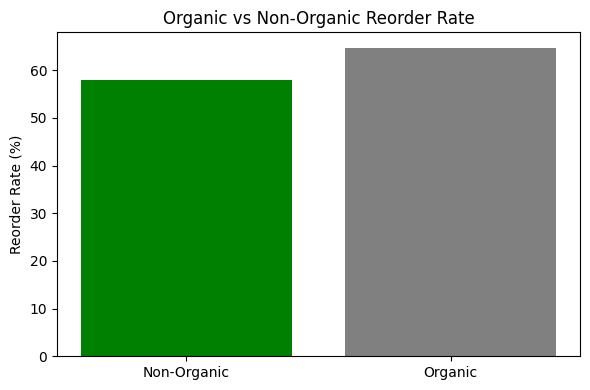

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from src.data_loader import load_order_products_train, load_product_lookup

train    = load_order_products_train()
products = load_product_lookup()

# Flag organic products
products['is_organic'] = products['product_name'].str.contains(
    'Organic', case=False, na=False
)

# Join and compute reorder rate
merged = train.merge(products[['product_id','is_organic','department']], on='product_id')

organic_rate = (merged.groupby('is_organic')['reordered']
                .mean()
                .reset_index())
organic_rate['label'] = organic_rate['is_organic'].map({True: 'Organic', False: 'Non-Organic'})

print(organic_rate[['label','reordered']])

plt.figure(figsize=(6, 4))
plt.bar(organic_rate['label'], organic_rate['reordered']*100, color=['green','gray'])
plt.ylabel('Reorder Rate (%)')
plt.title('Organic vs Non-Organic Reorder Rate')
plt.tight_layout()
plt.savefig('../docs/eda/organic_vs_nonorganic.png', dpi=150)
plt.show()

Section 2 — Add-to-Cart Position vs Reorder Probability

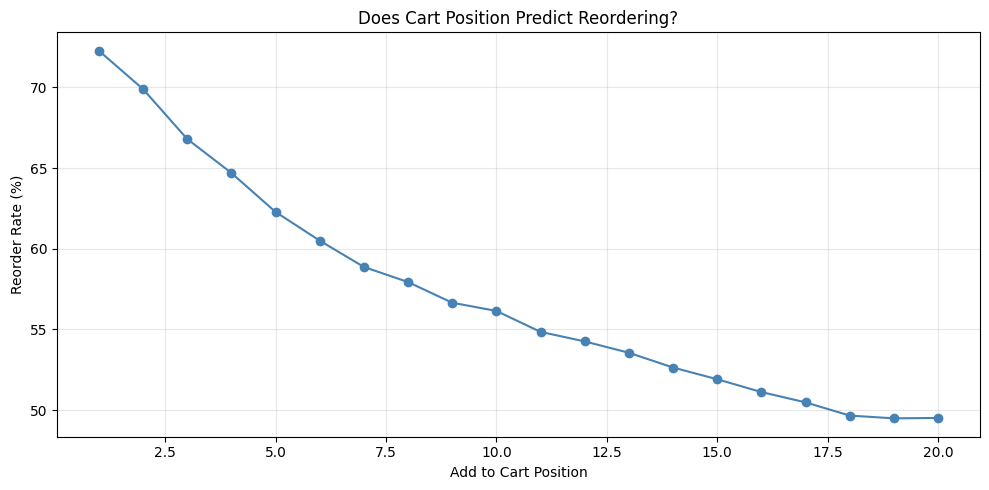

In [2]:
# Does being added to cart earlier mean more likely to be reordered?
cart_reorder = (train.groupby('add_to_cart_order')['reordered']
                .mean()
                .reset_index()
                .rename(columns={'reordered': 'reorder_rate'})
                .head(20))  # first 20 positions

plt.figure(figsize=(10, 5))
plt.plot(cart_reorder['add_to_cart_order'],
         cart_reorder['reorder_rate']*100, marker='o', color='steelblue')
plt.xlabel('Add to Cart Position')
plt.ylabel('Reorder Rate (%)')
plt.title('Does Cart Position Predict Reordering?')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../docs/eda/cart_position_reorder.png', dpi=150)
plt.show()

Section 3 — Department Level Reorder Rates

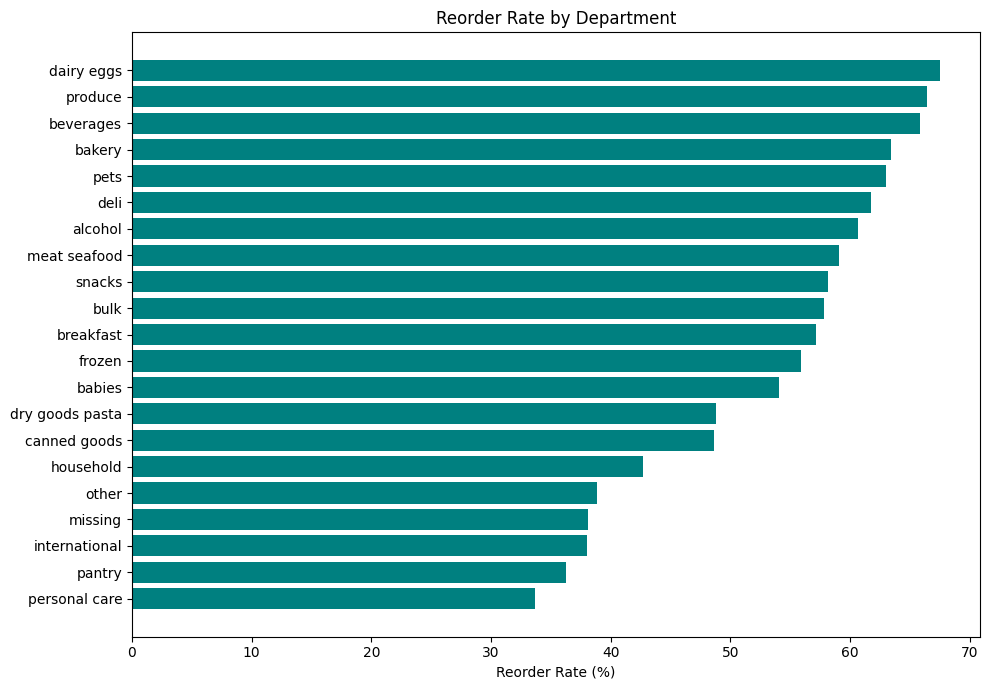

In [3]:
merged = train.merge(products[['product_id','department']], on='product_id')

dept_reorder = (merged.groupby('department')['reordered']
                .mean()
                .sort_values(ascending=True)
                .reset_index())

plt.figure(figsize=(10, 7))
plt.barh(dept_reorder['department'],
         dept_reorder['reordered']*100, color='teal')
plt.xlabel('Reorder Rate (%)')
plt.title('Reorder Rate by Department')
plt.tight_layout()
plt.savefig('../docs/eda/reorder_by_department.png', dpi=150)
plt.show()